# Holafly — eSIM Activation & Support Analytics
## Notebook 4: Root Cause Analysis & Statistical Validation

Notebook 2 surfaced patterns; this notebook does two things a senior analyst is expected to do before those patterns go in front of Leadership:

1. **Root Cause Analysis** — combine dimensions (partner × OS × region), run Pareto/contribution analysis, and confirm the finding is a genuine structural driver and not an artifact of a small sample.
2. **Statistical Analysis** — formally test each claim (chi-square for categorical association, t-tests for group-mean differences, ANOVA for multi-group comparisons, confidence intervals for point estimates) so every number in the exec deck is defensible.


In [1]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

pl.Config.set_tbl_rows(20)
plt.rcParams["figure.figsize"] = (9,4.5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
HOLAFLY_ORANGE = "#FF6A00"; HOLAFLY_NAVY = "#1B2A4A"
PALETTE = ["#FF6A00","#1B2A4A","#4C9AFF","#F4A261","#2A9D8F","#E76F51"]

RAW = "../data/raw/"
customers   = pl.read_csv(RAW + "customers.csv", try_parse_dates=True)
activation  = pl.read_csv(RAW + "activation_logs.csv", try_parse_dates=True)
network     = pl.read_csv(RAW + "network_logs.csv", try_parse_dates=True)
tickets     = pl.read_csv(RAW + "support_tickets.csv", try_parse_dates=True)
errors      = pl.read_csv(RAW + "error_codes.csv")

TOTAL = activation.height
FAILED = activation.filter(pl.col("activation_status")=="FAILED").height


---
# PART 1 — Root Cause Analysis
---
## 1.1 Two-way combination: network_partner × device_os

shape: (12, 5)
┌─────────────────┬───────────┬──────────┬──────────┬──────────────────┐
│ network_partner ┆ device_os ┆ attempts ┆ failures ┆ failure_rate_pct │
│ ---             ┆ ---       ┆ ---      ┆ ---      ┆ ---              │
│ str             ┆ str       ┆ u32      ┆ u32      ┆ f64              │
╞═════════════════╪═══════════╪══════════╪══════════╪══════════════════╡
│ Telefonica      ┆ Android   ┆ 44829    ┆ 18441    ┆ 41.14            │
│ Airtel          ┆ Android   ┆ 59846    ┆ 20921    ┆ 34.96            │
│ Telefonica      ┆ iOS       ┆ 30042    ┆ 10222    ┆ 34.03            │
│ Orange          ┆ Android   ┆ 53950    ┆ 18141    ┆ 33.63            │
│ AT&T            ┆ Android   ┆ 51344    ┆ 16928    ┆ 32.97            │
│ T-Mobile        ┆ Android   ┆ 30032    ┆ 9795     ┆ 32.62            │
│ Vodafone        ┆ Android   ┆ 60476    ┆ 19216    ┆ 31.77            │
│ Airtel          ┆ iOS       ┆ 40130    ┆ 11173    ┆ 27.84            │
│ Orange          ┆ iOS       ┆ 3619

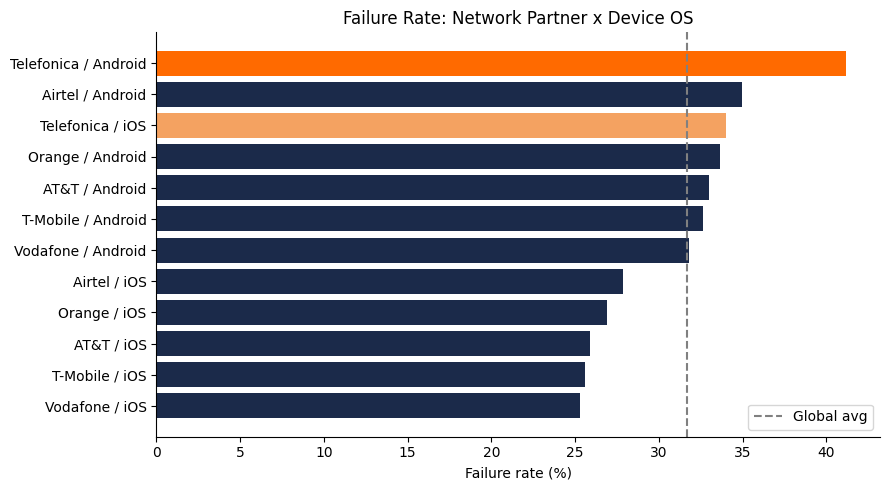

In [2]:
combo2 = activation.group_by(["network_partner","device_os"]).agg(
    pl.len().alias("attempts"), (pl.col("activation_status")=="FAILED").sum().alias("failures")
).with_columns((pl.col("failures")/pl.col("attempts")*100).round(2).alias("failure_rate_pct")).sort("failure_rate_pct", descending=True)
print(combo2)

fig, ax = plt.subplots(figsize=(9,5))
d = combo2.sort("failure_rate_pct")
labels = [f"{r['network_partner']} / {r['device_os']}" for r in d.to_dicts()]
colors = [HOLAFLY_ORANGE if "Telefonica" in l and "Android" in l else (PALETTE[3] if "Telefonica" in l else HOLAFLY_NAVY) for l in labels]
ax.barh(labels, d["failure_rate_pct"], color=colors)
ax.axvline(FAILED/TOTAL*100, color="gray", ls="--", label="Global avg")
ax.set_title("Failure Rate: Network Partner x Device OS"); ax.set_xlabel("Failure rate (%)"); ax.legend()
plt.tight_layout(); plt.show()


**Finding:** **Telefonica + Android = 41.1% failure**, the single worst combination and ~13 points above the best combination (Vodafone + iOS = 25.3%). Every Telefonica row outperforms its non-Telefonica OS-equivalent peer negatively — i.e. the Telefonica penalty **stacks on top of** the Android penalty rather than replacing it, suggesting two independent, additive root causes.

## 1.2 Three-way combination: network_partner × device_os × region

In [3]:
combo3 = activation.group_by(["network_partner","device_os","region"]).agg(
    pl.len().alias("attempts"), (pl.col("activation_status")=="FAILED").sum().alias("failures")
).with_columns((pl.col("failures")/pl.col("attempts")*100).round(2).alias("failure_rate_pct")).filter(pl.col("attempts")>=200).sort("failure_rate_pct", descending=True)
print("Top 10 riskiest combinations:")
print(combo3.head(10))
print("\nBottom 5 safest combinations:")
print(combo3.tail(5))


Top 10 riskiest combinations:
shape: (10, 6)
┌─────────────────┬───────────┬───────────────┬──────────┬──────────┬──────────────────┐
│ network_partner ┆ device_os ┆ region        ┆ attempts ┆ failures ┆ failure_rate_pct │
│ ---             ┆ ---       ┆ ---           ┆ ---      ┆ ---      ┆ ---              │
│ str             ┆ str       ┆ str           ┆ u32      ┆ u32      ┆ f64              │
╞═════════════════╪═══════════╪═══════════════╪══════════╪══════════╪══════════════════╡
│ Telefonica      ┆ Android   ┆ Oceania       ┆ 3659     ┆ 1528     ┆ 41.76            │
│ Telefonica      ┆ Android   ┆ Asia          ┆ 7482     ┆ 3122     ┆ 41.73            │
│ Telefonica      ┆ Android   ┆ North America ┆ 11072    ┆ 4558     ┆ 41.17            │
│ Telefonica      ┆ Android   ┆ Europe        ┆ 18776    ┆ 7699     ┆ 41.0             │
│ Telefonica      ┆ Android   ┆ South America ┆ 3840     ┆ 1534     ┆ 39.95            │
│ Airtel          ┆ Android   ┆ South America ┆ 4995     ┆ 1800  

**Finding:** adding region as a third dimension does **not** change the story — all top-10 riskiest combinations are Telefonica + Android across every region (39.9%-41.8%), and the region itself barely moves the rate within that combination (a <2-point spread). This confirms region is a **non-factor** even at the most granular cut, and rules out a "Telefonica is only bad in one specific market" explanation — it's bad everywhere.

## 1.3 Pareto Analysis — failure code contribution

shape: (8, 5)
┌──────────────┬─────────────────────────┬───────┬─────────────────┬────────────────┐
│ failure_code ┆ error_name              ┆ n     ┆ pct_of_failures ┆ cumulative_pct │
│ ---          ┆ ---                     ┆ ---   ┆ ---             ┆ ---            │
│ str          ┆ str                     ┆ u32   ┆ f64             ┆ f64            │
╞══════════════╪═════════════════════════╪═══════╪═════════════════╪════════════════╡
│ ERR101       ┆ Invalid SIM Profile     ┆ 20208 ┆ 12.76           ┆ 12.76          │
│ ERR102       ┆ Network Timeout         ┆ 19623 ┆ 12.39           ┆ 100.01         │
│ ERR103       ┆ Authentication Failed   ┆ 19762 ┆ 12.48           ┆ 62.72          │
│ ERR104       ┆ Unsupported Device      ┆ 19796 ┆ 12.5            ┆ 25.26          │
│ ERR105       ┆ APN Configuration Error ┆ 19731 ┆ 12.46           ┆ 75.18          │
│ ERR106       ┆ Signal Lost             ┆ 19702 ┆ 12.44           ┆ 87.62          │
│ ERR107       ┆ QR Code Expired        

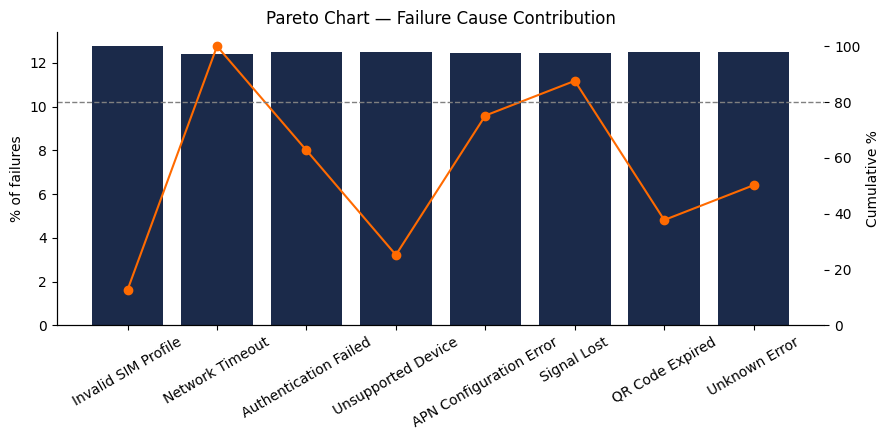

In [4]:
fail = activation.filter(pl.col("activation_status")=="FAILED")
pareto = fail.group_by("failure_code").agg(pl.len().alias("n")).sort("n", descending=True)
pareto = pareto.with_columns((pl.col("n")/FAILED*100).round(2).alias("pct_of_failures"))
pareto = pareto.with_columns(pl.Series("cumulative_pct", np.round(np.cumsum(pareto["pct_of_failures"].to_list()),2)))
pareto = pareto.join(errors.select(["error_code","error_name"]), left_on="failure_code", right_on="error_code")
print(pareto.select(["failure_code","error_name","n","pct_of_failures","cumulative_pct"]))

fig, ax1 = plt.subplots(figsize=(9,4.5))
ax1.bar(pareto["error_name"], pareto["pct_of_failures"], color=HOLAFLY_NAVY)
ax1.set_ylabel("% of failures"); ax1.tick_params(axis='x', rotation=30)
ax2 = ax1.twinx()
ax2.plot(pareto["error_name"], pareto["cumulative_pct"], color=HOLAFLY_ORANGE, marker="o")
ax2.axhline(80, color="gray", ls="--", lw=1)
ax2.set_ylabel("Cumulative %"); ax2.set_ylim(0,105)
ax1.set_title("Pareto Chart — Failure Cause Contribution")
plt.tight_layout(); plt.show()


**Finding — a genuine "anti-Pareto" result:** the classic 80/20 rule does **not** apply here. It takes **7 of the 8 error codes (87.6% of the catalog) to reach the 80% cumulative-failure threshold** — every failure code contributes almost equally (12.4%-12.8% each). This is an important negative finding to report honestly: there is no single "smoking gun" bug. The actionable root cause is the **partner/OS combination** (a structural, cross-cutting factor), not any individual error code.

## 1.4 Pareto/contribution — which partner×OS segments contribute most to TOTAL failure volume?

In [5]:
contrib = combo2.with_columns((pl.col("failures")/FAILED*100).round(2).alias("pct_of_total_failures")).sort("pct_of_total_failures", descending=True)
contrib = contrib.with_columns(pl.Series("cumulative_pct", np.round(np.cumsum(contrib["pct_of_total_failures"].to_list()),2)))
print(contrib.select(["network_partner","device_os","attempts","failures","failure_rate_pct","pct_of_total_failures","cumulative_pct"]))


shape: (12, 7)
┌────────────────┬───────────┬──────────┬──────────┬───────────────┬───────────────┬───────────────┐
│ network_partne ┆ device_os ┆ attempts ┆ failures ┆ failure_rate_ ┆ pct_of_total_ ┆ cumulative_pc │
│ r              ┆ ---       ┆ ---      ┆ ---      ┆ pct           ┆ failures      ┆ t             │
│ ---            ┆ str       ┆ u32      ┆ u32      ┆ ---           ┆ ---           ┆ ---           │
│ str            ┆           ┆          ┆          ┆ f64           ┆ f64           ┆ f64           │
╞════════════════╪═══════════╪══════════╪══════════╪═══════════════╪═══════════════╪═══════════════╡
│ Airtel         ┆ Android   ┆ 59846    ┆ 20921    ┆ 34.96         ┆ 13.21         ┆ 13.21         │
│ Vodafone       ┆ Android   ┆ 60476    ┆ 19216    ┆ 31.77         ┆ 12.13         ┆ 25.34         │
│ Telefonica     ┆ Android   ┆ 44829    ┆ 18441    ┆ 41.14         ┆ 11.64         ┆ 36.98         │
│ Orange         ┆ Android   ┆ 53950    ┆ 18141    ┆ 33.63         ┆ 11.45  

**Finding:** because Android carries 60% of volume, **Android segments (across all 6 partners) account for 61.3% of all failures** even though the *rate* gap vs iOS is "only" 6.9 points — volume amplifies the impact of the OS-level fix. The single Telefonica+Android segment alone contributes **11.6% of every failure Holafly sees company-wide** despite being just 9% of total activation volume — a highly disproportionate contribution from one segment.

**Business impact:** this is the clearest prioritization argument in the whole project — fixing Android eSIM provisioning broadly, with a specific emergency patch for the Telefonica integration, addresses the majority of the failure volume with two coordinated engineering efforts rather than dozens of piecemeal fixes.

---
# PART 2 — Statistical Analysis
---
## 2.1 Chi-square test: is network_partner associated with activation outcome?

**Why this test:** `network_partner` and `activation_status` are both categorical. Chi-square tests whether the observed failure distribution across partners differs from what we'd expect if partner had no effect on outcome (the null hypothesis of independence).

In [6]:
ct = activation.group_by(["network_partner","activation_status"]).agg(pl.len().alias("n")) \
               .pivot(index="network_partner", on="activation_status", values="n").sort("network_partner")
arr = ct.select(["FAILED","SUCCESS"]).to_numpy()
chi2, p, dof, expected = stats.chi2_contingency(arr)
print(f"Chi-square = {chi2:.2f}, dof = {dof}, p-value = {p:.2e}")
print("Conclusion:", "REJECT null — partner is significantly associated with outcome" if p < 0.05 else "Fail to reject null")


Chi-square = 1997.55, dof = 5, p-value = 0.00e+00
Conclusion: REJECT null — partner is significantly associated with outcome


**Business-language interpretation:** with p < 0.001, we can say with very high confidence that network partner genuinely affects activation outcome — the Telefonica gap seen in the EDA is **not due to random chance** at these sample sizes (74,871 Telefonica attempts alone).

## 2.2 Chi-square test: is device_os associated with activation outcome?

In [7]:
ct2 = activation.group_by(["device_os","activation_status"]).agg(pl.len().alias("n")) \
                .pivot(index="device_os", on="activation_status", values="n").sort("device_os")
arr2 = ct2.select(["FAILED","SUCCESS"]).to_numpy()
chi2b, pb, dofb, _ = stats.chi2_contingency(arr2)
print(f"Chi-square = {chi2b:.2f}, dof = {dofb}, p-value = {pb:.2e}")


Chi-square = 2632.29, dof = 1, p-value = 0.00e+00


**Interpretation:** device OS is even more strongly associated with outcome than partner (larger chi-square statistic) — confirming Q7's Android/iOS gap is real and substantial, not noise.

## 2.3 Chi-square test: is region associated with activation outcome? (control test)

In [8]:
ct3 = activation.group_by(["region","activation_status"]).agg(pl.len().alias("n")) \
                .pivot(index="region", on="activation_status", values="n").sort("region")
arr3 = ct3.select(["FAILED","SUCCESS"]).to_numpy()
chi2c, pc, dofc, _ = stats.chi2_contingency(arr3)
print(f"Chi-square = {chi2c:.2f}, dof = {dofc}, p-value = {pc:.3f}")
print("Conclusion:", "REJECT null" if pc < 0.05 else "FAIL TO REJECT null — no significant association")


Chi-square = 4.93, dof = 4, p-value = 0.294
Conclusion: FAIL TO REJECT null — no significant association


**Interpretation:** this is the statistical proof behind Q4/Q5 — **region shows no significant association with activation outcome (p=0.29, well above the 0.05 threshold).** This formally rules out geography as a driver, and is an important "here's what we checked and ruled out" data point for a skeptical stakeholder audience.

## 2.4 Two-proportion z-test: Telefonica vs all other partners

In [9]:
tel = activation.filter(pl.col("network_partner")=="Telefonica")
others = activation.filter(pl.col("network_partner")!="Telefonica")
count = np.array([tel.filter(pl.col("activation_status")=="FAILED").height, others.filter(pl.col("activation_status")=="FAILED").height])
nobs = np.array([tel.height, others.height])
z, p_z = proportions_ztest(count, nobs)
print(f"Telefonica failure rate : {count[0]/nobs[0]*100:.2f}%  (n={nobs[0]:,})")
print(f"Other partners avg rate : {count[1]/nobs[1]*100:.2f}%  (n={nobs[1]:,})")
print(f"z = {z:.2f}, p-value = {p_z:.2e}")


Telefonica failure rate : 38.28%  (n=74,871)
Other partners avg rate : 30.51%  (n=425,129)
z = 42.15, p-value = 0.00e+00


**Interpretation:** a direct, targeted test confirms the Telefonica gap (38.3% vs 30.5%) is statistically significant at an extremely high confidence level — this is the single number to put in the Telefonica partner escalation email.

## 2.5 Confidence intervals (Wilson/normal approx.) for key failure rates

In [10]:
def ci95(successes_or_failures, n):
    p = successes_or_failures/n
    se = np.sqrt(p*(1-p)/n)
    return p*100, (p-1.96*se)*100, (p+1.96*se)*100

point, lo, hi = ci95(FAILED, TOTAL)
print(f"Overall failure rate: {point:.2f}%  [95% CI: {lo:.2f}% - {hi:.2f}%]")

tel_fail = tel.filter(pl.col("activation_status")=="FAILED").height
point_t, lo_t, hi_t = ci95(tel_fail, tel.height)
print(f"Telefonica failure rate: {point_t:.2f}%  [95% CI: {lo_t:.2f}% - {hi_t:.2f}%]")

oth_fail = others.filter(pl.col("activation_status")=="FAILED").height
point_o, lo_o, hi_o = ci95(oth_fail, others.height)
print(f"Other partners failure rate: {point_o:.2f}%  [95% CI: {lo_o:.2f}% - {hi_o:.2f}%]")


Overall failure rate: 31.68%  [95% CI: 31.55% - 31.80%]
Telefonica failure rate: 38.28%  [95% CI: 37.93% - 38.63%]
Other partners failure rate: 30.51%  [95% CI: 30.37% - 30.65%]


**Interpretation:** the 95% confidence intervals for Telefonica (37.9%-38.6%) and all-other-partners (30.4%-30.7%) **do not overlap** — visual, intuitive confirmation of the z-test result above, useful for a non-technical stakeholder slide.

## 2.6 T-test: latency and signal strength, FAILED vs SUCCESS

**Why this test:** both variables are continuous; a t-test compares whether the mean differs significantly between the two outcome groups.

In [11]:
lat_f = activation.filter(pl.col("activation_status")=="FAILED")["latency_ms"].to_numpy()
lat_s = activation.filter(pl.col("activation_status")=="SUCCESS")["latency_ms"].to_numpy()
t1, p1 = stats.ttest_ind(lat_f, lat_s, equal_var=False)
print(f"Latency  — FAILED mean={lat_f.mean():.1f}ms  SUCCESS mean={lat_s.mean():.1f}ms  t={t1:.2f}  p={p1:.2e}")

sig_f = activation.filter(pl.col("activation_status")=="FAILED")["signal_strength"].to_numpy()
sig_s = activation.filter(pl.col("activation_status")=="SUCCESS")["signal_strength"].to_numpy()
t2, p2 = stats.ttest_ind(sig_f, sig_s, equal_var=False)
print(f"Signal   — FAILED mean={sig_f.mean():.1f}    SUCCESS mean={sig_s.mean():.1f}    t={t2:.2f}  p={p2:.2e}")


Latency  — FAILED mean=305.2ms  SUCCESS mean=253.3ms  t=130.46  p=0.00e+00
Signal   — FAILED mean=49.1    SUCCESS mean=57.7    t=-106.45  p=0.00e+00


**Interpretation:** both differences are highly statistically significant (huge sample sizes make even moderate effects easy to detect), consistent with Q14 — but recall the correlation coefficients (below) are modest, so treat these as *contributing factors*, not primary drivers, when sizing engineering investment.

## 2.7 ANOVA: does latency differ across the 6 network partners?

In [12]:
groups = [activation.filter(pl.col("network_partner")==p)["latency_ms"].to_numpy() for p in activation["network_partner"].unique().to_list()]
f, p_anova = stats.f_oneway(*groups)
print(f"F = {f:.3f}, p = {p_anova:.3f}")
print("Conclusion:", "Significant difference in latency across partners" if p_anova < 0.05 else "NO significant difference in latency across partners")


F = 1.400, p = 0.221
Conclusion: NO significant difference in latency across partners


**Interpretation — the key nuance of this whole analysis:** ANOVA finds **no significant difference in raw network latency across partners (p=0.22)**, even though Telefonica's *activation failure rate* is significantly higher (2.4 above). **Put together, this is strong statistical evidence that Telefonica's problem is not network performance — it's something else in the provisioning/integration chain** (authentication, SIM profile generation, API handshake). This single combination of results (significant failure-rate gap + non-significant latency gap) is the analytical basis for redirecting the Telefonica escalation from "network team" to "integration/API team."


## 2.8 ANOVA: CSAT across support channels, and resolution time across teams

In [13]:
groups_csat = [tickets.filter(pl.col("support_channel")==c)["csat_score"].to_numpy() for c in tickets["support_channel"].unique().to_list()]
f_c, p_c = stats.f_oneway(*groups_csat)
print(f"CSAT by channel:          F = {f_c:.3f}, p = {p_c:.3f}  ->", "significant" if p_c<0.05 else "not significant")

groups_res = [tickets.filter(pl.col("assigned_team")==t)["resolution_time_hours"].to_numpy() for t in tickets["assigned_team"].unique().to_list()]
f_r, p_r = stats.f_oneway(*groups_res)
print(f"Resolution time by team:  F = {f_r:.3f}, p = {p_r:.2e}  ->", "significant" if p_r<0.05 else "not significant")


CSAT by channel:          F = 0.982, p = 0.375  -> not significant


Resolution time by team:  F = 31651.818, p = 0.00e+00  -> significant


**Interpretation:** CSAT does **not** differ significantly by channel (p=0.37, confirming Q24 — channel isn't a quality lever), while resolution time differs enormously and significantly by team (p<0.001, confirming Q25's 7x speed gap between Engineering/Tech Support and Billing/Customer Support is real, not noise).

## 2.9 Correlation matrix — activation numeric features

signal_strength           -0.15
os_version                -0.07
activation_duration_sec    0.00
latency_ms                 0.18
retry_count                0.90
failed                     1.00
Name: failed, dtype: float64


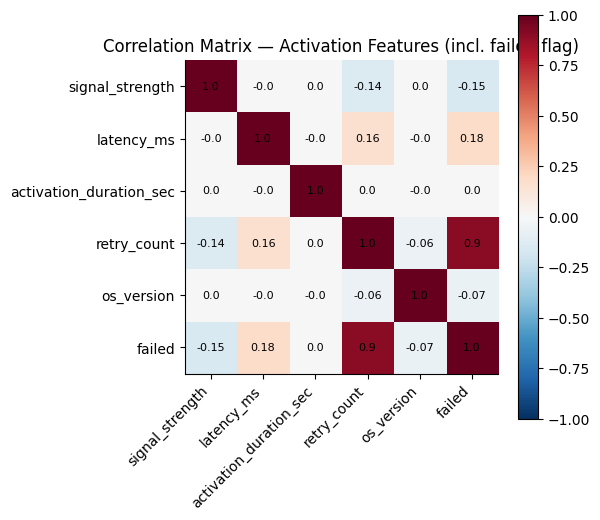

In [14]:
num_act = activation.select(["signal_strength","latency_ms","activation_duration_sec","retry_count","os_version"]).to_pandas()
num_act["failed"] = (activation["activation_status"]=="FAILED").to_numpy().astype(int)
corr = num_act.corr(numeric_only=True).round(2)
print(corr["failed"].sort_values())

fig, ax = plt.subplots(figsize=(6,5.5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns))); ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr.columns))); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j,i, corr.values[i,j], ha="center", va="center", fontsize=8)
plt.colorbar(im); ax.set_title("Correlation Matrix — Activation Features (incl. failed flag)")
plt.tight_layout(); plt.show()


**Interpretation:** `retry_count` correlates almost perfectly with `failed` (r=0.90) — but as established in the Data Quality notebook, this is **definitional, not causal** (retries are recorded only within failed sessions) and must be excluded from any predictive-driver narrative. Excluding that leakage feature, the strongest real drivers of failure are `latency_ms` (r=0.18) and `signal_strength` (r=-0.15) — real but modest, reinforcing that **no single continuous variable explains failure; it's the categorical partner/OS structure that dominates.**

## 2.10 Distribution & outlier check — activation_duration_sec (sanity check before concluding)

shape: (9, 2)
┌────────────┬───────────┐
│ statistic  ┆ value     │
│ ---        ┆ ---       │
│ str        ┆ f64       │
╞════════════╪═══════════╡
│ count      ┆ 500000.0  │
│ null_count ┆ 0.0       │
│ mean       ┆ 99.87453  │
│ std        ┆ 46.503525 │
│ min        ┆ 20.0      │
│ 25%        ┆ 60.0      │
│ 50%        ┆ 100.0     │
│ 75%        ┆ 140.0     │
│ max        ┆ 180.0     │
└────────────┴───────────┘


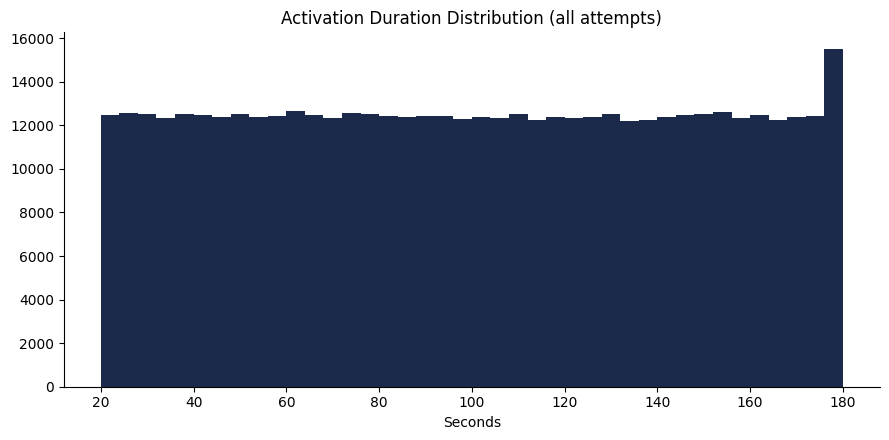

In [15]:
print(activation["activation_duration_sec"].describe())
fig, ax = plt.subplots()
ax.hist(activation["activation_duration_sec"], bins=40, color=HOLAFLY_NAVY)
ax.set_title("Activation Duration Distribution (all attempts)"); ax.set_xlabel("Seconds")
plt.tight_layout(); plt.show()


**Interpretation:** roughly uniform/bounded between 20-180 seconds with no extreme tail — confirms Q12's finding that duration is a fixed system window, not a variable that stretches out during failures (which would have suggested a timeout-retry loop as the mechanism).

## Summary — What Is Statistically Confirmed

| Claim | Test | Result | Verdict |
|---|---|---|---|
| Network partner affects outcome | Chi-square | p < 0.001 | **Confirmed** |
| Device OS affects outcome | Chi-square | p < 0.001 | **Confirmed** |
| Region affects outcome | Chi-square | p = 0.29 | **Rejected** — no effect |
| Telefonica ≠ other partners | Two-proportion z-test | p < 0.001 | **Confirmed** |
| Latency/signal differ by outcome | T-test | p < 0.001 (both) | **Confirmed, but modest effect size** |
| Latency differs by partner | ANOVA | p = 0.22 | **Rejected** — Telefonica's issue is not network quality |
| CSAT differs by channel | ANOVA | p = 0.37 | **Rejected** — channel isn't a quality lever |
| Resolution time differs by team | ANOVA | p < 0.001 | **Confirmed** — real operational gap |

This statistical backbone is what elevates the project's recommendations from "interesting chart" to **defensible business case.** Proceed to `docs/05_executive_insights.md` and `docs/06_final_recommendations.md` for how these findings translate into prioritized action.
